In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr 
import tams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
import seaborn as sns
import os
import numpy as np
import analysis_functions_2 as af2

from joblib import Parallel, delayed
from scipy.stats import gaussian_kde


import warnings
warnings.filterwarnings('ignore')

* Extracted from tams_predata.ipynb

* In order to take care of some nan values found in ctt, we're going to crop the lon coordinates as they are the main problem (see nan_check for more information)

In [ ]:
root = "./"
pr_pre = "precipitation_IMERG_1999_WA" # This can be changed to match the data and resolution.
data_path_pr = f"{root}TFM/{pr_pre}_0.25x0.25.nc"

temp_pre = "tb_merg_1999_WA" # This can be changed to match the data and resolution.
data_path_temp = f"{root}TFM/{temp_pre}_0.25x0.25.nc"

CHUNK_T = 96   # tune: bigger → more RAM, fewer tasks; 96 ≈ 2 days of 30-min steps

pr_data = (
    xr.open_dataset(data_path_pr,   chunks={"time": CHUNK_T, "lat": -1, "lon": -1})
      .transpose("time", "lat", "lon")
      .rename({"precipitation": "pr"})
)
temp_data = (
    xr.open_dataset(data_path_temp, chunks={"time": CHUNK_T, "lat": -1, "lon": -1})
      .rename({"Tb": "ctt"})
)

tbI = temp_data["ctt"].dropna(dim='time', how='all')
tp  = pr_data["pr"]

# Interpolate in order to make merge faster for different resolutions
#pr_data = pr_data.interp_like(temp_data, method='nearest')

- Let's fix the exact timestamp where we have a row full of nans. I'll skip them, returning an empty GeoDataFrame for that moment. 

In [ ]:
ds = xr.Dataset({'tb': tbI, 'tp': tp})

cesI, _ = tams.identify(tbI.compute(), parallel=True);

cesI_all = af2.Parallel_nan_ds(cesI, ds)

In [ ]:
cesI_c = cesI_all.copy()
print(len(cesI_all), len(cesI_c))
print(True if cesI_all == cesI_c else False)

- Do tracking

In [ ]:
proj = -10
times = tbI.time.values.tolist()

ces_T = tams.track(cesI, times, u_projection=-10) #Change cesI to cesI_c to test

In [ ]:
ce_clasI = tams.classify(ces_T)

## Other Year

In [2]:
root = "./"
pr_pre = "precipitation_IMERG_2024_WA" # This can be changed to match the data and resolution.
data_path_pr = f"{root}TFM/{pr_pre}_0.25x0.25.nc"

temp_pre = "tb_merg_2024_WA" # This can be changed to match the data and resolution.
data_path_temp = f"{root}TFM/{temp_pre}_0.25x0.25.nc"

CHUNK_T = 96 

pr_data = (
    xr.open_dataset(data_path_pr,   chunks={"time": CHUNK_T, "lat": -1, "lon": -1})
      .transpose("time", "lat", "lon")
      .rename({"precipitation": "pr"})
)
temp_data = (
    xr.open_dataset(data_path_temp, chunks={"time": CHUNK_T, "lat": -1, "lon": -1})
      .rename({"Tb": "ctt"})
)
tbI = temp_data["ctt"]#.dropna(dim='time', how='all')
tp  = pr_data["pr"]


In [3]:
ds = xr.Dataset({'tb': tbI, 'tp': tp})
timeI = tbI.time.values.tolist()

cesI, _ = tams.identify(tbI.compute(), parallel=True);




[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   24.0s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:   28.4s
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:   29.7s
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:   31.4s
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:   

In [ ]:
cesI_all = af2.Parallel_ds(cesI, ds)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   14.4s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:   15.0s
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:   16.7s
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:   17.8s
[Parallel(n_jobs=2)]: Done  21 tasks      | elapsed:   20.1s
[Parallel(n_jobs=2)]: Done  28 tasks      | elapsed:   21.8s
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:   24.4s
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   26.9s
[Parallel(n_jobs=2)]: Done  57 tasks      | elapsed:   29.7s
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:   32.7s
[Parallel(n_jobs=2)]: Done  81 tasks      | elapsed:   37.2s
[Parallel(n_jobs=2)]: Done  94 tasks      | elapsed:   41.2s
[Parallel(n_jobs=2)]: Done 109 tasks      | elapsed:   44.5s
[Parallel(n_jobs=2)]: Done 124 tasks      | elapsed:   48.3s
[Parallel(n_jobs=2)]: Done 141 tasks      | elapsed:   53.0s
[Parallel(

ValueError: Encountered an empty CE frame. If your dataset has NaN timestamps, use enrich_ces_parallel_nan() instead.

In [6]:
# Añado variables de interés a los ces identificados:
def fun(ds,ce):
    if not ce.empty:
        ce = tams.data_in_contours(ds.tb, ce, agg=("mean", "min","max"), merge=True)
        ce = tams.data_in_contours(ds.tp, ce, agg=("mean","min", "max"), merge=True)
    return ce

cesI_all = Parallel(n_jobs=-2, verbose=10)(
    delayed(fun)(ds.isel(time=i).copy(deep=False),ce.copy())
    for i, ce in enumerate(cesI)
)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   24.6s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:   31.1s
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:   44.0s
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:   

In [7]:
cesI_c = cesI_all.copy()
print(type(cesI_c))

<class 'list'>


In [ ]:
af2.save_parquet(cesI_c, "tams_2024_025")

In [8]:
ces_par = af2.list_from_parquet("./parquet_sets/tams_2024_025.parquet", len(tbI.time))
proj = -10
times = tbI.time.values.tolist()



- We compare two methods, they should be the same and work perfectly.

In [9]:
ces_T = tams.track(ces_par, times, u_projection=-10)

In [10]:
ces_t = tams.track(cesI_c, times, u_projection=-10)

In [ ]:
cesI_c.groupby(["mcs_id", "mcs_class"], observed=True)

- Idem.

In [11]:
ce_clasI = tams.classify(ces_T)

In [12]:
ce_clas_i = tams.classify(ces_t)

In [ ]:
af2.dibujoMCS(ce_clasI)

In [24]:
ce_clas_i

,geometry,area_km2,inds219,area219_km2,cs219,mean_tb,min_tb,max_tb,mean_tp,min_tp,max_tp,time,itime,dtime,mcs_id,mcs_class
0,"POLYGON ((35 6.425, 35.25 6.43, 35.34211 6.5, ...",12960.465272,[1],4452.241131,"MULTIPOLYGON (((35 6.59091, 35.5 6.99, 35.51 7...",222.722222,210,243,7.227776,0.341738,18.962599,2024-06-01 00:00:00,0,0 days 00:30:00,0.0,DSL
1,"POLYGON ((33.25 4.8125, 33.5 4.91667, 33.55952...",9202.116686,[2],4106.135194,"MULTIPOLYGON (((33.25 5.01389, 33.5 5.06522, 3...",219.142857,202,231,2.088786,-0.0,7.46688,2024-06-01 00:00:00,0,0 days 00:30:00,1.0,DSL
2,"POLYGON ((27.5 0.92347, 28.5 1.13333, 28.69444...",36029.590128,"[3, 4]",8610.457553,"MULTIPOLYGON (((27.5 1.01667, 28.15 1.25, 28.0...",224.204545,204,241,2.094311,-0.000001,9.337635,2024-06-01 00:00:00,0,0 days 00:30:00,2.0,DSL
3,"POLYGON ((24 4.60417, 25 4.64286, 25.25 4.75, ...",291912.708822,"[5, 6]",158030.949686,"MULTIPOLYGON (((23.25 4.94444, 23.5 4.95833, 2...",221.164894,198,268,2.928151,-0.000002,23.756615,2024-06-01 00:00:00,0,0 days 00:30:00,3.0,MCC
4,"POLYGON ((10.75 5.14773, 13.25 5.17683, 14.25 ...",107724.585895,"[7, 8, 9]",50688.502635,"MULTIPOLYGON (((14.25 5.40909, 14.41667 5.5, 1...",225.48951,200,269,1.361847,-0.00003,9.363482,2024-06-01 00:00:00,0,0 days 00:30:00,4.0,DLL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62065,"POLYGON ((-12 7.25, -11.5 7.75, -11.33333 8, -...",44713.840104,[29],24231.785369,"MULTIPOLYGON (((-13 7.48571, -12.94444 7.5, -1...",219.224138,201,245,2.440427,0.134844,8.623871,2024-09-30 23:30:00,5855,0 days 00:30:00,7849.0,DSL
62066,"POLYGON ((-25 9.52778, -24.65625 9.75, -24.566...",46515.894786,"[30, 31, 32]",10333.985830,"MULTIPOLYGON (((-25 11.6875, -24.83333 11.75, ...",224.813559,206,265,2.186639,0.14405,6.761884,2024-09-30 23:30:00,5855,0 days 00:30:00,7845.0,DSL
62067,"POLYGON ((-25.75 4.31944, -25.5 4.46739, -25.4...",68633.103524,"[33, 34, 35, 36]",6226.185897,"MULTIPOLYGON (((-25.75 4.6875, -25.5 4.75, -25...",234.402174,212,272,1.328264,-0.000039,7.496769,2024-09-30 23:30:00,5855,0 days 00:30:00,7851.0,DSL
62068,"POLYGON ((-34.5 9.45, -33.75 9.75, -33 10.1538...",360425.255734,"[38, 39, 40]",194090.271189,"MULTIPOLYGON (((-34.5 9.95, -33.5 10.3, -32.75...",224.800857,200,269,2.2907,-0.000021,16.619793,2024-09-30 23:30:00,5855,0 days 00:30:00,7768.0,MCC


In [32]:
def _add_spatial_temporal_cols(ce: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Derive cent_lat, cent_lon, and day_yr from geometry and time.
    Returns a copy with the new columns added.
    """
    ce = ce.copy()
    centroids = ce.geometry.to_crs(epsg=3857).centroid.to_crs(epsg=4326)
    ce["cent_lat"] = centroids.y
    ce["cent_lon"] = centroids.x
    ce["day_yr"]   = ce["time"].dt.dayofyear
    return ce

ce_ex = _add_spatial_temporal_cols(ce_clasI[ce_clasI["mcs_class"] == "MCC"])
ce_ex

,geometry,area_km2,inds219,area219_km2,cs219,mean_tb,min_tb,max_tb,mean_tp,min_tp,max_tp,time,itime,dtime,mcs_id,mcs_class,cent_lat,cent_lon,day_yr
3,"POLYGON ((24 4.60417, 25 4.64286, 25.25 4.75, ...",291912.708822,"[5, 6]",158030.949686,"MULTIPOLYGON (((23.25 4.944444444444445, 23.5 ...",221.164894,198,268,2.928151,-0.000002,23.756615,2024-06-01 00:00:00,0,0 days 00:30:00,3.0,MCC,7.773684,22.500190,153
16,"POLYGON ((23.5 4.45312, 23.75 4.45588, 23.8571...",286808.866785,"[6, 7]",156327.489829,"MULTIPOLYGON (((23.5 4.875, 24.5 5.4375, 24.53...",221.191892,199,268,2.556588,-0.000007,21.186693,2024-06-01 00:30:00,1,0 days 00:30:00,3.0,MCC,7.766261,22.188560,153
29,"POLYGON ((23.25 4.35938, 23.5 4.375, 24.33333 ...",298844.775821,"[6, 7]",173299.373268,"MULTIPOLYGON (((23.25 4.694444444444445, 23.33...",222.835052,196,274,2.059081,-0.000007,13.693203,2024-06-01 01:00:00,2,0 days 00:30:00,3.0,MCC,7.787600,22.090529,153
41,"POLYGON ((23 4.21591, 23.1875 4.25, 23.25 4.27...",302754.8621,"[5, 6, 7]",176280.674389,"MULTIPOLYGON (((23 4.625, 23.75 5.25, 24 5.5, ...",224.440204,196,282,2.292997,-0.000005,13.677871,2024-06-01 01:30:00,3,0 days 00:30:00,3.0,MCC,7.760365,21.995922,153
49,"POLYGON ((33 4.625, 35 6.35, 35.08654 6.5, 35....",63347.999608,[2],34838.511854,"MULTIPOLYGON (((32.75 4.954545454545454, 32.87...",224.26506,192,278,3.400239,-0.000004,21.602398,2024-06-01 02:00:00,4,0 days 00:30:00,15.0,MCC,6.242264,33.740309,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62041,"POLYGON ((-34.25 9.70588, -33.5 10.26786, -33....",388760.970873,"[37, 38, 39, 40, 41]",173204.819024,"MULTIPOLYGON (((-34.5 10.183333333333334, -34....",225.911243,197,275,2.390199,-0.000003,25.555405,2024-09-30 22:30:00,5853,0 days 00:30:00,7768.0,MCC,12.875577,-35.954838,274
62054,"POLYGON ((-34.75 9.67308, -34.5 9.75, -34.25 9...",308939.077001,"[34, 35]",223279.964402,"MULTIPOLYGON (((-34.5 10, -33.5 10.46875, -33....",222.472362,198,267,2.65808,-0.000001,22.98398,2024-09-30 23:00:00,5854,0 days 00:30:00,7768.0,MCC,12.643374,-35.214039,274
62055,"POLYGON ((-38 12.075, -37.86538 12.25, -37.475...",56769.29044,[36],11057.510261,"MULTIPOLYGON (((-38.5 12.928571428571429, -38....",232.583333,214,277,0.162194,-0.000004,0.460323,2024-09-30 23:00:00,5854,0 days 00:30:00,7768.0,MCC,14.095268,-38.305806,274
62068,"POLYGON ((-34.5 9.45, -33.75 9.75, -33 10.1538...",360425.255734,"[38, 39, 40]",194090.271189,"MULTIPOLYGON (((-34.5 9.95, -33.5 10.3, -32.75...",224.800857,200,269,2.2907,-0.000021,16.619793,2024-09-30 23:30:00,5855,0 days 00:30:00,7768.0,MCC,12.562927,-34.890722,274


- BUILD A FUNCTION TO TEST THEN PASS IT TO LIBRARY.

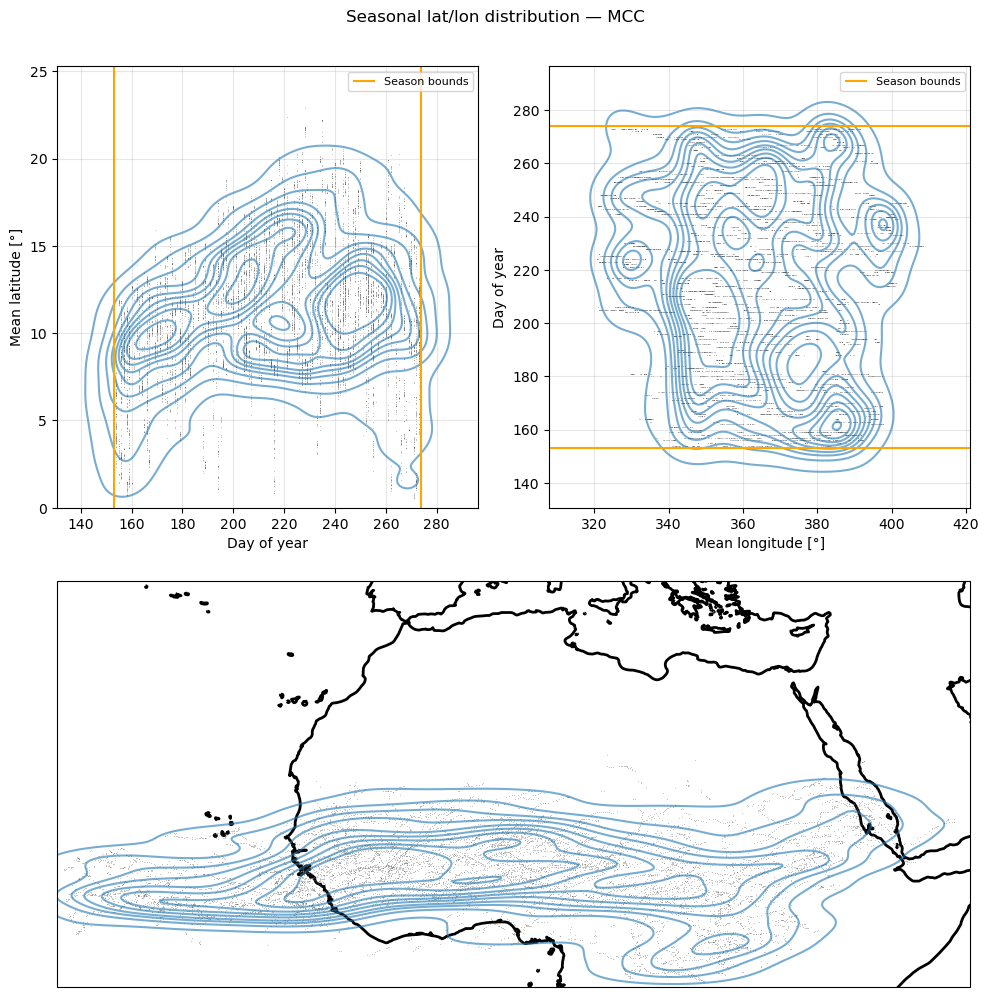

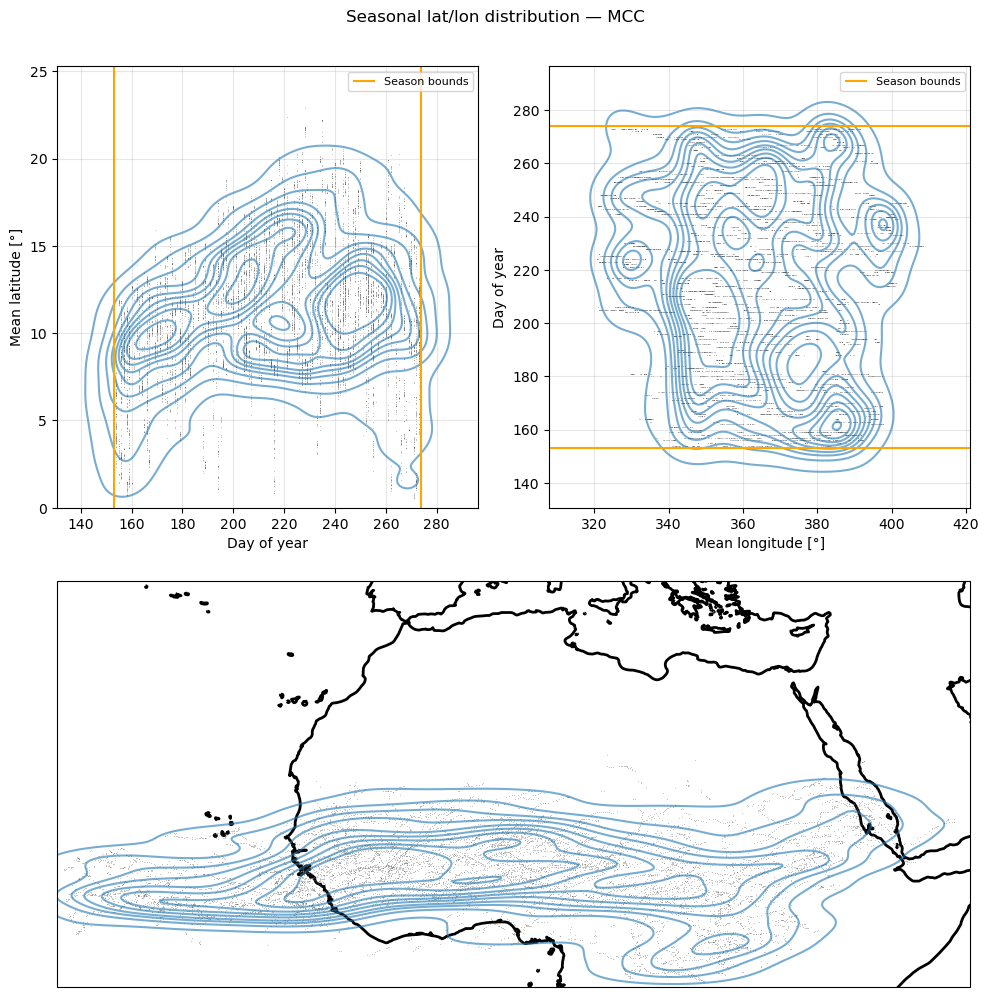

In [30]:
_MCS_ORDER = ["DSL", "DLL", "CCC", "MCC"] # This follows Nunez Ocasio Classification
_KDE_KWARGS = dict(fill=False, alpha=0.6, common_norm=True)
_SAHEL_EXTENT = (lonmin, lonmax, latmin, latmax) = (-40,50,0,40) #(°W, °E, °S, °N)

def _kde_scatter(ax, data:pd.DataFrame, x: str, y:str, clip=None):
    """Auxiliar funciton - Scatter + KDE overlay on a given axis."""

    ax.plot(data[x], data[y], ".", ms=1, mec="none", mfc="0.35", alpha=0.9)
    sns.kdeplot(
        x=x, y=y,
        color= sns.color_palette()[0],
        clip=clip,
        ax=ax,
        data=data,
        **_KDE_KWARGS,
    )

def seasonal_latlon(
        tbI: xr.DataArray,
        ce_clasI: gpd.GeoDataFrame,
        mcs_class: str,
) -> plt.Figure:
    """
    Plot the seasonal (day-of-year) relationship between MCS location for a
    given MCS class, across three panels:
 
      1. Day-of-year vs latitude
      2. Longitude vs day-of-year
      3. Map: longitude vs latitude with coastlines
 
    The map extent is inferred automatically from the data, with an optional
    padding applied on each side.
 
    Parameters
    ----------
    tbI : xr.DataArray
        Brightness temperature array with a 'time' coordinate in datetime
        format. Used only to derive the season boundaries (first/last day
        of year).
    ce_clasI : gpd.GeoDataFrame
        GeoDataFrame produced by ``tams.classify()``. Must contain columns:
        'mcs_class', 'cent_lat', 'cent_lon', 'day_yr', 'mcs_id', 'itime'.
    mcs_class : str
        MCS class to plot. Must be one of 'DSL', 'DLL', 'CCC', 'MCC'.
 
    Returns
    -------
    matplotlib.figure.Figure
    """

    if mcs_class not in _MCS_ORDER:
        raise ValueError(f"mcs_class must be one of {_MCS_ORDER}, got {mcs_class!r}")
    
    start = int(tbI.time.min().dt.dayofyear)
    end = int(tbI.time.max().dt.dayofyear)

    ce = _add_spatial_temporal_cols(ce_clasI[ce_clasI["mcs_class"] == mcs_class])

    if ce.empty:
        raise ValueError(f"No data found for mcs_class={mcs_class!r}.")
    
    gb = ce.groupby(['mcs_id', 'itime'])
    stats = pd.DataFrame({
        "day_yr": gb.day_yr.mean().astype(float),
        "cent_lat": gb.cent_lat.mean().astype(float),
        "cent_lon": gb.cent_lon.mean().astype(float) + 360,
    })

    lonmin, lonmax, latmin, latmax = _SAHEL_EXTENT
 
    # ── Figure ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle(f"Seasonal lat/lon distribution — {mcs_class}", y=1.01)
 
    # Panel 1: day-of-year vs latitude
    ax1 = fig.add_subplot(2, 2, 1)
    _kde_scatter(ax1, stats, x="day_yr", y="cent_lat", clip=(0, None))
    ylim = ax1.get_ylim()
    ax1.vlines([start, end], *ylim, colors="orange", label="Season bounds")
    ax1.set_ylim(ylim)
    ax1.set_xlabel("Day of year")
    ax1.set_ylabel("Mean latitude [°]")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
 
    # Panel 2: longitude vs day-of-year
    ax2 = fig.add_subplot(2, 2, 2)
    _kde_scatter(ax2, stats, x="cent_lon", y="day_yr", clip=(0, None))
    xlim = ax2.get_xlim()
    ax2.hlines([start, end], *xlim, colors="orange", label="Season bounds")
    ax2.set_xlim(xlim)
    ax2.set_xlabel("Mean longitude [°]")
    ax2.set_ylabel("Day of year")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
 
    # Panel 3: map
    ax3 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
    stats_map = stats.copy()
    stats_map["cent_lon"] -= 360  # restore -180/180 for PlateCarree
 
    _kde_scatter(ax3, stats_map, x="cent_lon", y="cent_lat")
    ax3.coastlines(linewidth=2)
    ax3.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    ax3.set_xlabel("Longitude [°]")
    ax3.set_ylabel("Latitude [°]")
 
    fig.tight_layout()
    return fig

seasonal_latlon(tbI, ce_clasI, "MCC")

In [33]:
print(len(ce_clasI))                  # number of CE rows
print(ce_clasI.mcs_id.nunique()) 

62070
7852
